### PREPARATION

In [114]:
import yaml
import logging
import pypsa
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import sys
import matplotlib.lines as mlines
from matplotlib.patches import Wedge

In [115]:
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
warnings.simplefilter(action='ignore', category=ResourceWarning)

desal = pypsa.Network("../../../pypsa-earth/results/desal/postnetworks/elec_s_13_ec_lcopt_Co2L0.15_3H_2050_0.086_NZ_499.5export.nc")
desalx2 = pypsa.Network("../../../pypsa-earth/results/desalx2/postnetworks/elec_s_13_ec_lcopt_Co2L0.15_3H_2050_0.086_NZ_499.5export.nc")
desalx4 = pypsa.Network("../../../pypsa-earth/results/desalx4/postnetworks/elec_s_13_ec_lcopt_Co2L0.15_3H_2050_0.086_NZ_499.5export.nc")
wodesal = pypsa.Network("../../../pypsa-earth/results/woDesal/postnetworks/elec_s_13_ec_lcopt_Co2L0.15_3H_2050_0.086_NZ_499.5export.nc")

# Load geographic data for onshore regions and ports
regions_onshore = gpd.read_file("../../../pypsa-earth/resources/shapes/country_shapes.geojson")
ports = pd.read_csv("../../../pypsa-earth/resources/desal/ports.csv")

# Create a GeoDataFrame for ports with point geometries
ports = gpd.GeoDataFrame(
    ports,
    geometry=gpd.points_from_xy(ports["x"], ports["y"]),
    crs="EPSG:4326"  # Coordinates are in WGS84
)

# Load GADM shapes and configuration file
gadm_shapes = gpd.read_file("../../../pypsa-earth/resources/shapes/gadm_shapes.geojson")
config = yaml.safe_load(open("../../../pypsa-earth/config.yaml"))

# Define paths for network and renewable profiles
network_path = "../../../pypsa-earth/networks/desal/elec.nc"
solar_path = "../../../pypsa-earth/resources/desal/renewable_profiles/profile_solar.nc"
onwind_path = "../../../pypsa-earth/resources/desal/renewable_profiles/profile_onwind.nc"

# Get the bounding box for the onshore regions
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]

# Define colors for scenarios
SCENARIO_COLORS = {"desal": "#1f77b4", "wodesal": "#ff7f0e"}
tech_colors = config["plotting"]["tech_colors"]

# Normalize the carrier column/index to lowercase for easier matching
def get_color(carrier):
    # First, check for an exact match
    if carrier in tech_colors:
        return tech_colors[carrier]
    # Try matching with lowercase
    if carrier.lower() in tech_colors:
        return tech_colors[carrier.lower()]
    # Default color if no match is found
    return "lightgrey"

# Map colors to carriers in the  network
desal.carriers["color"] = desal.carriers.index.map(get_color)
desalx2.carriers["color"] = desalx2.carriers.index.map(get_color)
desalx4.carriers["color"] = desalx4.carriers.index.map(get_color)
wodesal.carriers["color"] = wodesal.carriers.index.map(get_color)


warnings.simplefilter(action='default', category=ResourceWarning)

#### Show initial energy system design

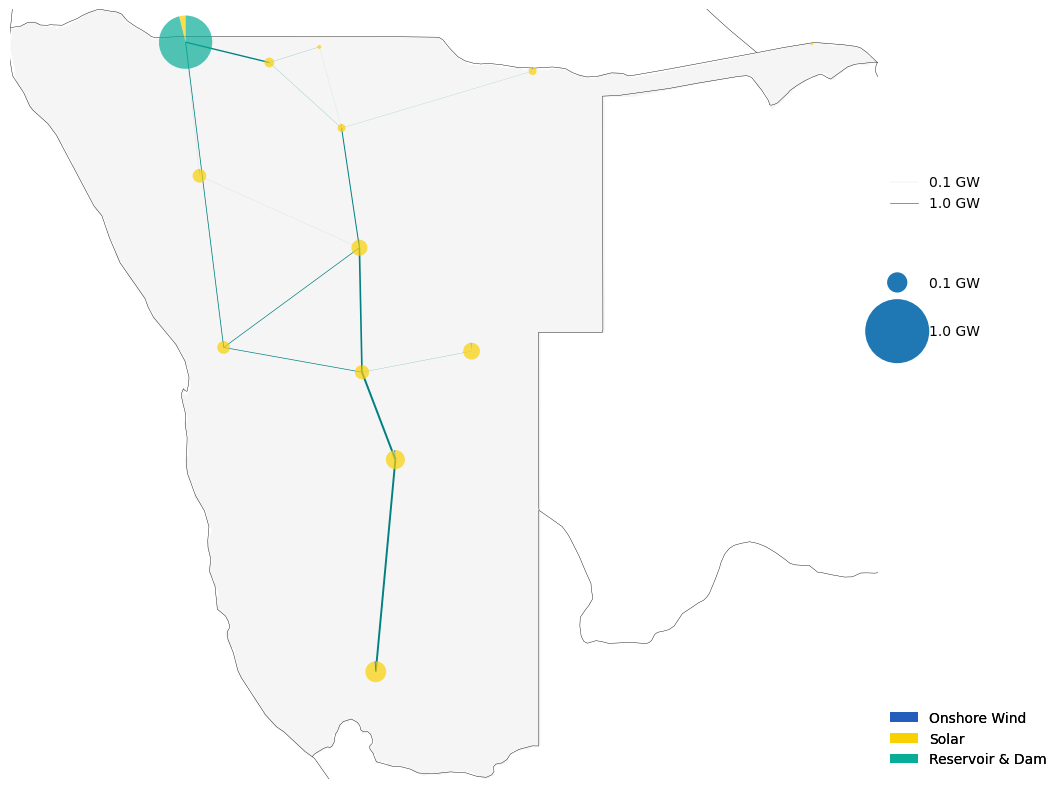

In [116]:
warnings.simplefilter(action='ignore', category=UserWarning)

# -----------------------------
# Carrier mapping (IMPORTANT)
# -----------------------------
CARRIER_AGG_MAP = {
    "CCGT": "gas",   # Combined-Cycle Gas -> gas
}

def map_carrier(c):
    return CARRIER_AGG_MAP.get(c, c)

# -----------------------------
# Ensure all carriers have color and nice_name
# -----------------------------
missing_carriers = [
    'lignite', 'coal', 'solar rooftop', 'oil', 'gas',
    'residential rural solar thermal',
    'residential urban decentral solar thermal',
    'services rural solar thermal',
    'services urban decentral solar thermal',
    'urban central solar thermal',
    'CCGT'
]

carrier_color_mapping = {
    'lignite': 'coal',
    'solar rooftop': 'solar',
    'residential rural solar thermal': 'solar',
    'residential urban decentral solar thermal': 'solar',
    'services rural solar thermal': 'solar',
    'services urban decentral solar thermal': 'solar',
    'urban central solar thermal': 'solar',
    'CCGT': 'gas'
}


def apply_carrier_styling(n, missing_carriers, carrier_color_mapping):
    # create rows if missing
    for c in missing_carriers:
        if c not in n.carriers.index:
            n.carriers.loc[c, :] = np.nan

    # colors
    for c, ref in carrier_color_mapping.items():
        if ref in n.carriers.index and pd.notna(n.carriers.loc[ref, "color"]):
            n.carriers.loc[c, "color"] = n.carriers.loc[ref, "color"]
        else:
            n.carriers.loc[c, "color"] = "gray"

    # nice_names
    if "coal" in n.carriers.index:
        n.carriers.loc["coal", "nice_name"] = "Coal"
    if "oil" in n.carriers.index:
        n.carriers.loc["oil", "nice_name"] = "Oil"
    if "gas" in n.carriers.index:
        n.carriers.loc["gas", "nice_name"] = "Gas"
    if "CCGT" in n.carriers.index:
        # still exists as a carrier, but will be aggregated to 'gas'
        n.carriers.loc["CCGT", "nice_name"] = "Gas"

    for c, ref in carrier_color_mapping.items():
        if c != "CCGT" and ref in n.carriers.index:
            n.carriers.loc[c, "nice_name"] = n.carriers.loc[ref, "nice_name"]

    # fallbacks
    n.carriers["color"] = n.carriers["color"].replace("", np.nan).fillna("gray")
    n.carriers["nice_name"] = (
        n.carriers["nice_name"]
        .replace("", np.nan)
        .fillna(pd.Series(n.carriers.index, index=n.carriers.index))
    )

    # remove load shedding
    for cand in ["load shedding", "Load shedding"]:
        if cand in n.carriers.index:
            n.carriers.drop(cand, inplace=True)

# Apply to both
apply_carrier_styling(desal, missing_carriers, carrier_color_mapping)
apply_carrier_styling(wodesal, missing_carriers, carrier_color_mapping)

# -----------------------------
# Scale settings
# -----------------------------
bus_scale = 2e3
line_scale = 2e3
bus_sizes = [100, 1000]   # MW
line_sizes = [100, 1000]  # MW

# -----------------------------
# Aggregate generator and storage capacities by bus and *aggregated* carrier
# -----------------------------
gen = desal.generators[desal.generators.carrier != "load shedding"].copy()
gen["carrier_agg"] = gen["carrier"].map(map_carrier)
gen = gen.groupby(["bus", "carrier_agg"]).p_nom.sum()

sto = desal.storage_units.copy()
sto["carrier_agg"] = sto["carrier"].map(map_carrier)
sto = sto.groupby(["bus", "carrier_agg"]).p_nom.sum()

buses = pd.concat([gen, sto])

# -----------------------------
# Plotting
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Filter Links: only those that lie within GADM regions
link_bus0_base = desal.links.bus0.str.split("_AC").str[0]
link_bus1_base = desal.links.bus1.str.split("_AC").str[0]

valid_links = desal.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (desal.links.p_nom > 0)
]

links_backup = desal.links
desal.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    desal.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=desal.lines.s_nom / line_scale,
        link_widths=desal.links.p_nom / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )

regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)

ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# -----------------------------
# Legends
# -----------------------------
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)

# Carrier legend: build from carriers actually used after aggregation
used_carriers_agg = buses.index.get_level_values(1).unique()

colors_legend = []
labels_legend = []
seen = set()

for c in used_carriers_agg:
    # use aggregated carrier's style (e.g., 'gas' not 'CCGT')
    if c in desal.carriers.index:
        name = desal.carriers.loc[c, 'nice_name']
        color = desal.carriers.loc[c, 'color']
    else:
        name = str(c)
        color = "gray"

    val_total = buses.xs(c, level=1).sum() if c in used_carriers_agg else 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()
plt.show()

# Restore original links
desal.links = links_backup
warnings.simplefilter(action='default', category=UserWarning)


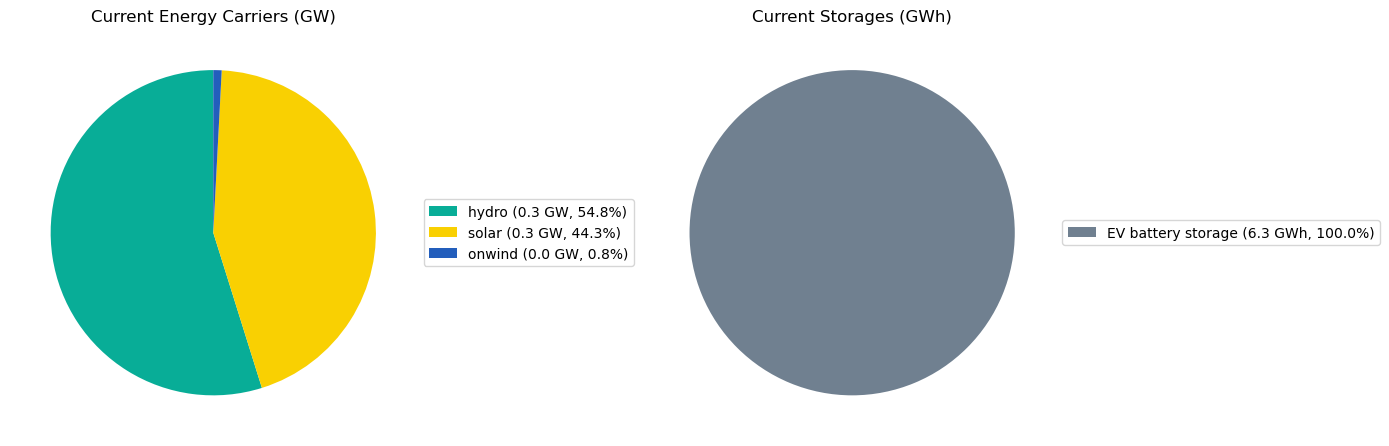

In [117]:
# --- Extract data for current energy carriers ---
energy_carriers = pd.concat([desal.generators[~desal.generators.carrier.str.contains("load", case=False)][["carrier", "p_nom"]], desal.storage_units[["carrier", "p_nom"]]]).groupby("carrier").p_nom.sum().div(1e3).sort_values(ascending=False)

# --- Extract data for current storages ---
storages = (
    desal.stores.groupby("carrier")
    .e_nom.sum()
    .div(1e3)  # Convert to GWh
    .sort_values(ascending=False)
)

# --- Filter: keep only entries > 0 ---
energy_carriers = energy_carriers[energy_carriers > 0]
storages = storages[storages > 0]
storages = storages[~storages.index.isin(["solid biomass", "biogas"])]

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- Energy carriers ---
energy_colors = [get_color(c) for c in energy_carriers.index]
wedges1, _ = axes[0].pie(
    energy_carriers,
    labels=None,   # no labels directly in the chart
    startangle=90,
    colors=energy_colors
)
axes[0].set_title("Current Energy Carriers (GW)")

# Legend with capacity + share
labels1 = [
    f"{c} ({v:.1f} GW, {100*v/energy_carriers.sum():.1f}%)"
    for c, v in zip(energy_carriers.index, energy_carriers.values)
]
axes[0].legend(
    wedges1,
    labels1,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# --- Storages ---
storage_colors = [get_color(c) for c in storages.index]
wedges2, _ = axes[1].pie(
    storages,
    labels=None,
    startangle=90,
    colors=storage_colors
)
axes[1].set_title("Current Storages (GWh)")

# Legend with capacity + share
labels2 = [
    f"{c} ({v:.1f} GWh, {100*v/storages.sum():.1f}%)"
    for c, v in zip(storages.index, storages.values)
]
axes[1].legend(
    wedges2,
    labels2,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()


#### Compare energy system with desalination and without

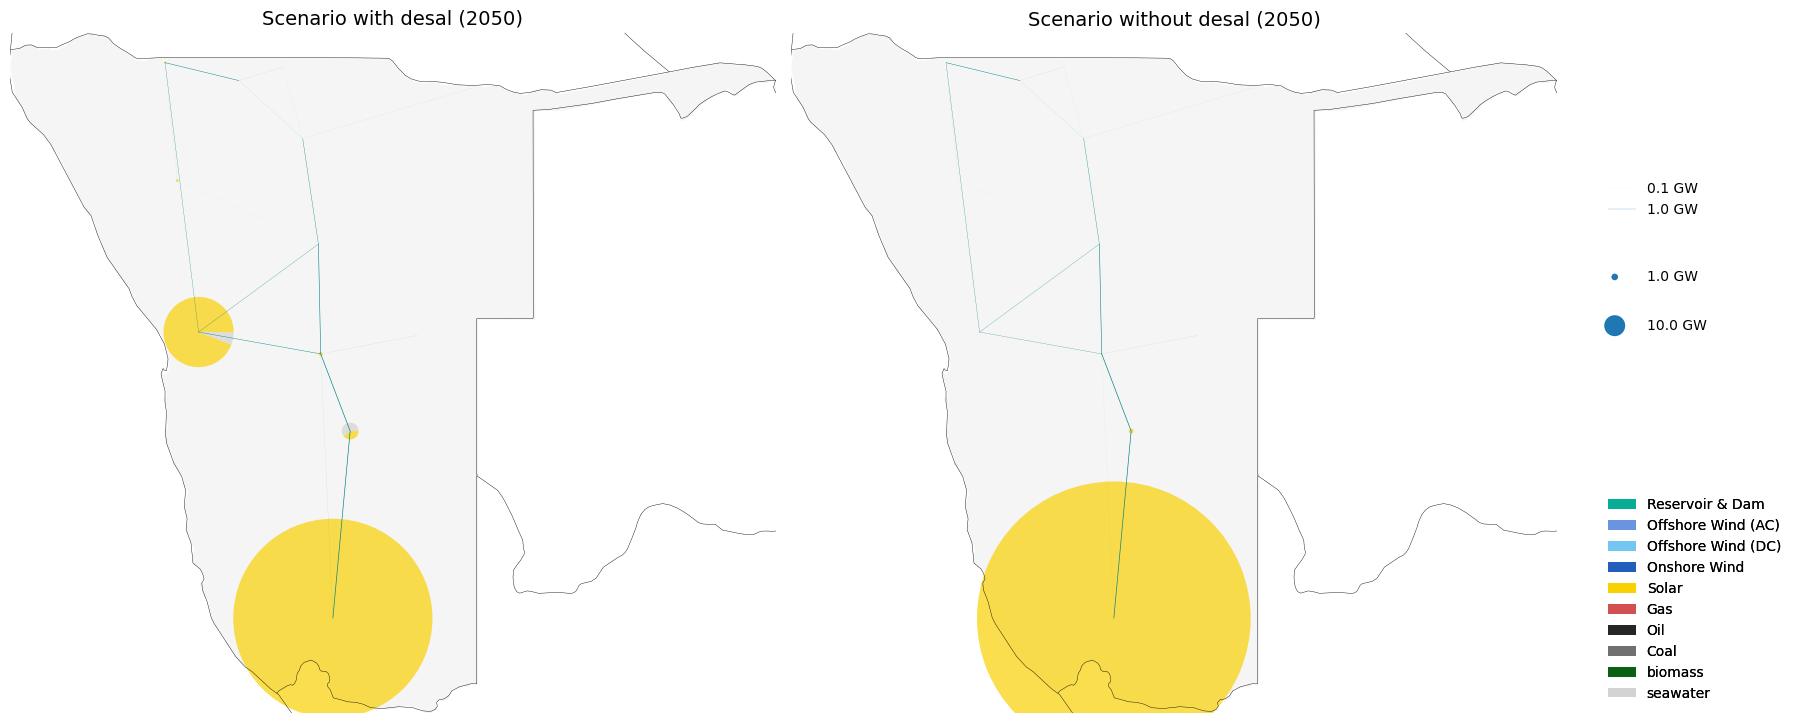

In [118]:
# Plot energy system desal and woDesal 2050 on a map next to each other
warnings.simplefilter(action="ignore", category=UserWarning)

# -----------------------------
# Carrier preparation (colors + nice_name)
# -----------------------------
carrier_color_mapping = {
    "lignite": "coal",
    "solar rooftop": "solar",
    "residential rural solar thermal": "solar",
    "residential urban decentral solar thermal": "solar",
    "services rural solar thermal": "solar",
    "services urban decentral solar thermal": "solar",
    "urban central solar thermal": "solar",
    "ccgt": "gas",
}

CARRIER_AGG_MAP = {
    "CCGT": "gas",   # Combined-Cycle Gas -> gas
}

def prepare_carriers(n):
    n = n.copy()

    if "color" not in n.carriers.columns:
        n.carriers["color"] = np.nan
    if "nice_name" not in n.carriers.columns:
        n.carriers["nice_name"] = n.carriers.index

    for c, ref in carrier_color_mapping.items():
        if c not in n.carriers.index:
            n.carriers.loc[c, ["color", "nice_name"]] = [np.nan, c.replace("_", " ").capitalize()]

        if ref in n.carriers.index and pd.notna(n.carriers.loc[ref, "color"]) and n.carriers.loc[ref, "color"] != "":
            n.carriers.loc[c, "color"] = n.carriers.loc[ref, "color"]
        else:
            n.carriers.loc[c, "color"] = "gray"

        if c != "ccgt" and ref in n.carriers.index and pd.notna(n.carriers.loc[ref, "nice_name"]):
            n.carriers.loc[c, "nice_name"] = n.carriers.loc[ref, "nice_name"]

    if "coal" in n.carriers.index:
        n.carriers.loc["coal", "nice_name"] = "Coal"
    if "oil" in n.carriers.index:
        n.carriers.loc["oil", "nice_name"] = "Oil"
    if "gas" in n.carriers.index:
        n.carriers.loc["gas", "nice_name"] = "Gas"
    if "ccgt" in n.carriers.index:
        n.carriers.loc["ccgt", "nice_name"] = "Gas"
        if (pd.isna(n.carriers.loc["ccgt", "color"]) or n.carriers.loc["ccgt", "color"] == "") and "gas" in n.carriers.index:
            gcol = n.carriers.loc["gas", "color"]
            if pd.notna(gcol) and gcol != "":
                n.carriers.loc["ccgt", "color"] = gcol

    n.carriers["color"] = n.carriers["color"].replace("", np.nan).fillna("gray")
    n.carriers["nice_name"] = (
        n.carriers["nice_name"]
        .replace("", np.nan)
        .fillna(pd.Series(n.carriers.index, index=n.carriers.index))
    )

    for cand in ["Load shedding", "load shedding"]:
        if cand in n.carriers.index:
            n.carriers = n.carriers.drop(cand)

    return n

# -----------------------------
# Hub mapping via coordinates (generalized)
# -----------------------------
def build_hub_mapping(n, min_cluster_size=2):
    """
    A hub is defined as a coordinate cluster (x,y) that contains at least min_cluster_size buses.
    This automatically excludes global / non-spatial buses that don't share coordinates with others.

    Returns:
      bus_to_hub: Series mapping bus -> hub_id
      hub_coords: DataFrame mapping hub_id -> x,y
    """
    buses_xy = n.buses[["x", "y"]].copy()

    # Ensure numeric and drop missing coordinates
    buses_xy["x"] = pd.to_numeric(buses_xy["x"], errors="coerce")
    buses_xy["y"] = pd.to_numeric(buses_xy["y"], errors="coerce")
    buses_xy = buses_xy.dropna(subset=["x", "y"])

    grouped = buses_xy.groupby(["x", "y"], sort=False)

    bus_to_hub = {}
    hub_coords = {}
    hub_id = 0

    for (x, y), df in grouped:
        if len(df) < min_cluster_size:
            continue
        hid = f"hub_{hub_id}"
        hub_id += 1

        for bus in df.index:
            bus_to_hub[bus] = hid
        hub_coords[hid] = {"x": x, "y": y}

    bus_to_hub = pd.Series(bus_to_hub, dtype="object")
    hub_coords = pd.DataFrame.from_dict(hub_coords, orient="index")

    return bus_to_hub, hub_coords

# -----------------------------
# Aggregation: Generators + StorageUnits by hub & carrier
# -----------------------------
def aggregate_gen_sto_by_hub(n, bus_to_hub):
    parts = []

    if len(n.generators):
        gen = n.generators[n.generators.carrier != "load shedding"].copy()
        gen["hub"] = gen["bus"].map(bus_to_hub)
        gen = gen.dropna(subset=["hub"])

        # <-- entscheidend: carrier für Aggregation mappen
        gen["carrier_agg"] = gen["carrier"].replace(CARRIER_AGG_MAP)

        parts.append(gen.groupby(["hub", "carrier_agg"])["p_nom_opt"].sum())

    if len(n.storage_units):
        sto = n.storage_units.copy()
        sto["hub"] = sto["bus"].map(bus_to_hub)
        sto = sto.dropna(subset=["hub"])

        sto["carrier_agg"] = sto["carrier"].replace(CARRIER_AGG_MAP)

        parts.append(sto.groupby(["hub", "carrier_agg"])["p_nom_opt"].sum())

    if not parts:
        return pd.Series(dtype=float)

    return pd.concat(parts).groupby(level=[0, 1]).sum()

# -----------------------------
# Draw one pie per hub
# -----------------------------
def draw_pies(ax, hubs_caps, hub_coords, carriers_df, bus_scale, alpha=0.7, radius_mode="linear"):
    if hubs_caps.empty or hub_coords.empty:
        return

    hub_totals = hubs_caps.groupby(level=0).sum()

    for hub, total in hub_totals.items():
        if total <= 0 or hub not in hub_coords.index:
            continue

        x, y = hub_coords.loc[hub, ["x", "y"]]

        if radius_mode == "sqrt":
            r = np.sqrt(total / bus_scale)
        else:
            r = total / bus_scale

        s = hubs_caps.xs(hub, level=0)
        s = s[s > 0].sort_values(ascending=False)
        if s.empty:
            continue

        start = 0.0
        denom = s.sum()

        for carrier, val in s.items():
            end = start + (val / denom) * 360.0

            color = "gray"
            if carrier in carriers_df.index and "color" in carriers_df.columns:
                c = carriers_df.loc[carrier, "color"]
                if pd.notna(c) and c != "":
                    color = c

            ax.add_patch(
                Wedge(
                    (x, y), r, start, end,
                    facecolor=color, edgecolor="none", alpha=alpha,
                    transform=ccrs.PlateCarree(),
                )
            )
            start = end

# -----------------------------
# Plot routine: network lines/links via PyPSA, pies drawn manually
# -----------------------------
def plot_network_one_pie_per_location(
    n, ax, title, gadm_shapes, regions_onshore,
    bus_scale, line_scale, min_cluster_size=2, pie_alpha=0.7, pie_radius_mode="linear"
):
    bus_to_hub, hub_coords = build_hub_mapping(n, min_cluster_size=min_cluster_size)
    hubs_caps = aggregate_gen_sto_by_hub(n, bus_to_hub)

    # Suppress PyPSA bus glyphs; we draw pies ourselves
    zero_bus_sizes = pd.Series(0.0, index=n.buses.index)

    # Filter links for plotting ONLY (still excluded from pies)
    link_bus0_base = n.links.bus0.str.split("_AC").str[0]
    link_bus1_base = n.links.bus1.str.split("_AC").str[0]
    valid_links = n.links[
        link_bus0_base.isin(gadm_shapes.index)
        & link_bus1_base.isin(gadm_shapes.index)
        & (n.links.p_nom_opt > 0)
    ]

    n_plot = n.copy()
    n_plot.links = valid_links

    # Background
    regions_onshore.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        transform=ccrs.PlateCarree(),
        linewidth=0,
    )

    with plt.rc_context({"patch.linewidth": 0.0}):
        n_plot.plot(
            bus_sizes=zero_bus_sizes,
            bus_alpha=0.0,
            line_widths=n_plot.lines.s_nom_opt / line_scale,
            link_widths=n_plot.links.p_nom_opt / line_scale,
            line_colors="teal",
            ax=ax,
            margin=0.2,
            color_geomap=None,
        )

    ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
    ax.set_title(title, fontsize=14)

    # Pies overlay
    draw_pies(
        ax, hubs_caps, hub_coords, n.carriers,
        bus_scale=bus_scale, alpha=pie_alpha, radius_mode=pie_radius_mode
    )

    # Return used carriers for legend building
    used_carriers = set()
    if len(n.generators):
        used_carriers |= set(n.generators.carrier.replace(CARRIER_AGG_MAP))
    if len(n.storage_units):
        used_carriers |= set(n.storage_units.carrier.replace(CARRIER_AGG_MAP))
    used_carriers.discard("load shedding")
    return used_carriers

# -----------------------------
# USER SETTINGS
# -----------------------------
bus_scale  = 2e5
line_scale = 6e3
bus_sizes_legend  = [1000, 10000]  # MW (legend only)
line_sizes_legend = [100, 1000]      # MW (legend only)

# Pie hub definition:
# - min_cluster_size=2 excludes coordinate singletons (typical global buses)
min_cluster_size = 2

# -----------------------------
# Run (two scenarios side-by-side)
# -----------------------------
desal_p   = prepare_carriers(desal)
wodesal_p = prepare_carriers(wodesal)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={"projection": ccrs.PlateCarree()})

used_0 = plot_network_one_pie_per_location(
    desal_p, axes[0], "Scenario with desal (2050)",
    gadm_shapes, regions_onshore,
    bus_scale, line_scale,
    min_cluster_size=min_cluster_size,
    pie_alpha=0.7,
    pie_radius_mode="linear",
)
used_1 = plot_network_one_pie_per_location(
    wodesal_p, axes[1], "Scenario without desal (2050)",
    gadm_shapes, regions_onshore,
    bus_scale, line_scale,
    min_cluster_size=min_cluster_size,
    pie_alpha=0.7,
    pie_radius_mode="linear",
)

# -----------------------------
# Legends (reuse your helpers)
# -----------------------------
legend_kwargs = {"loc": "upper left", "frameon": False}

add_legend_circles(
    axes[1],
    [s / bus_scale for s in bus_sizes_legend],
    [f"{s / 1000} GW" for s in bus_sizes_legend],
    legend_kw={"bbox_to_anchor": (1.05, 0.67), "labelspacing": 2.5, **legend_kwargs},
)
add_legend_lines(
    axes[1],
    [s / line_scale for s in line_sizes_legend],
    [f"{s / 1000} GW" for s in line_sizes_legend],
    legend_kw={"bbox_to_anchor": (1.05, 0.8), **legend_kwargs},
)

# Carrier legend: union across both scenarios, from generators + storage_units only
used_carriers = {CARRIER_AGG_MAP.get(c, c) for c in used_0.union(used_1)}

colors_legend, labels_legend, seen = [], [], set()
for c in desal_p.carriers.index:
    if c not in used_carriers:
        continue

    name = desal_p.carriers.loc[c, "nice_name"] if "nice_name" in desal_p.carriers.columns else c
    if pd.isna(name) or name == "":
        name = c.replace("_", " ").capitalize()

    color = desal_p.carriers.loc[c, "color"] if "color" in desal_p.carriers.columns else "gray"
    if pd.isna(color) or color == "":
        color = "gray"

    if name not in seen:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    axes[1],
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1.05, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()
plt.show()

warnings.simplefilter(action="default", category=UserWarning)

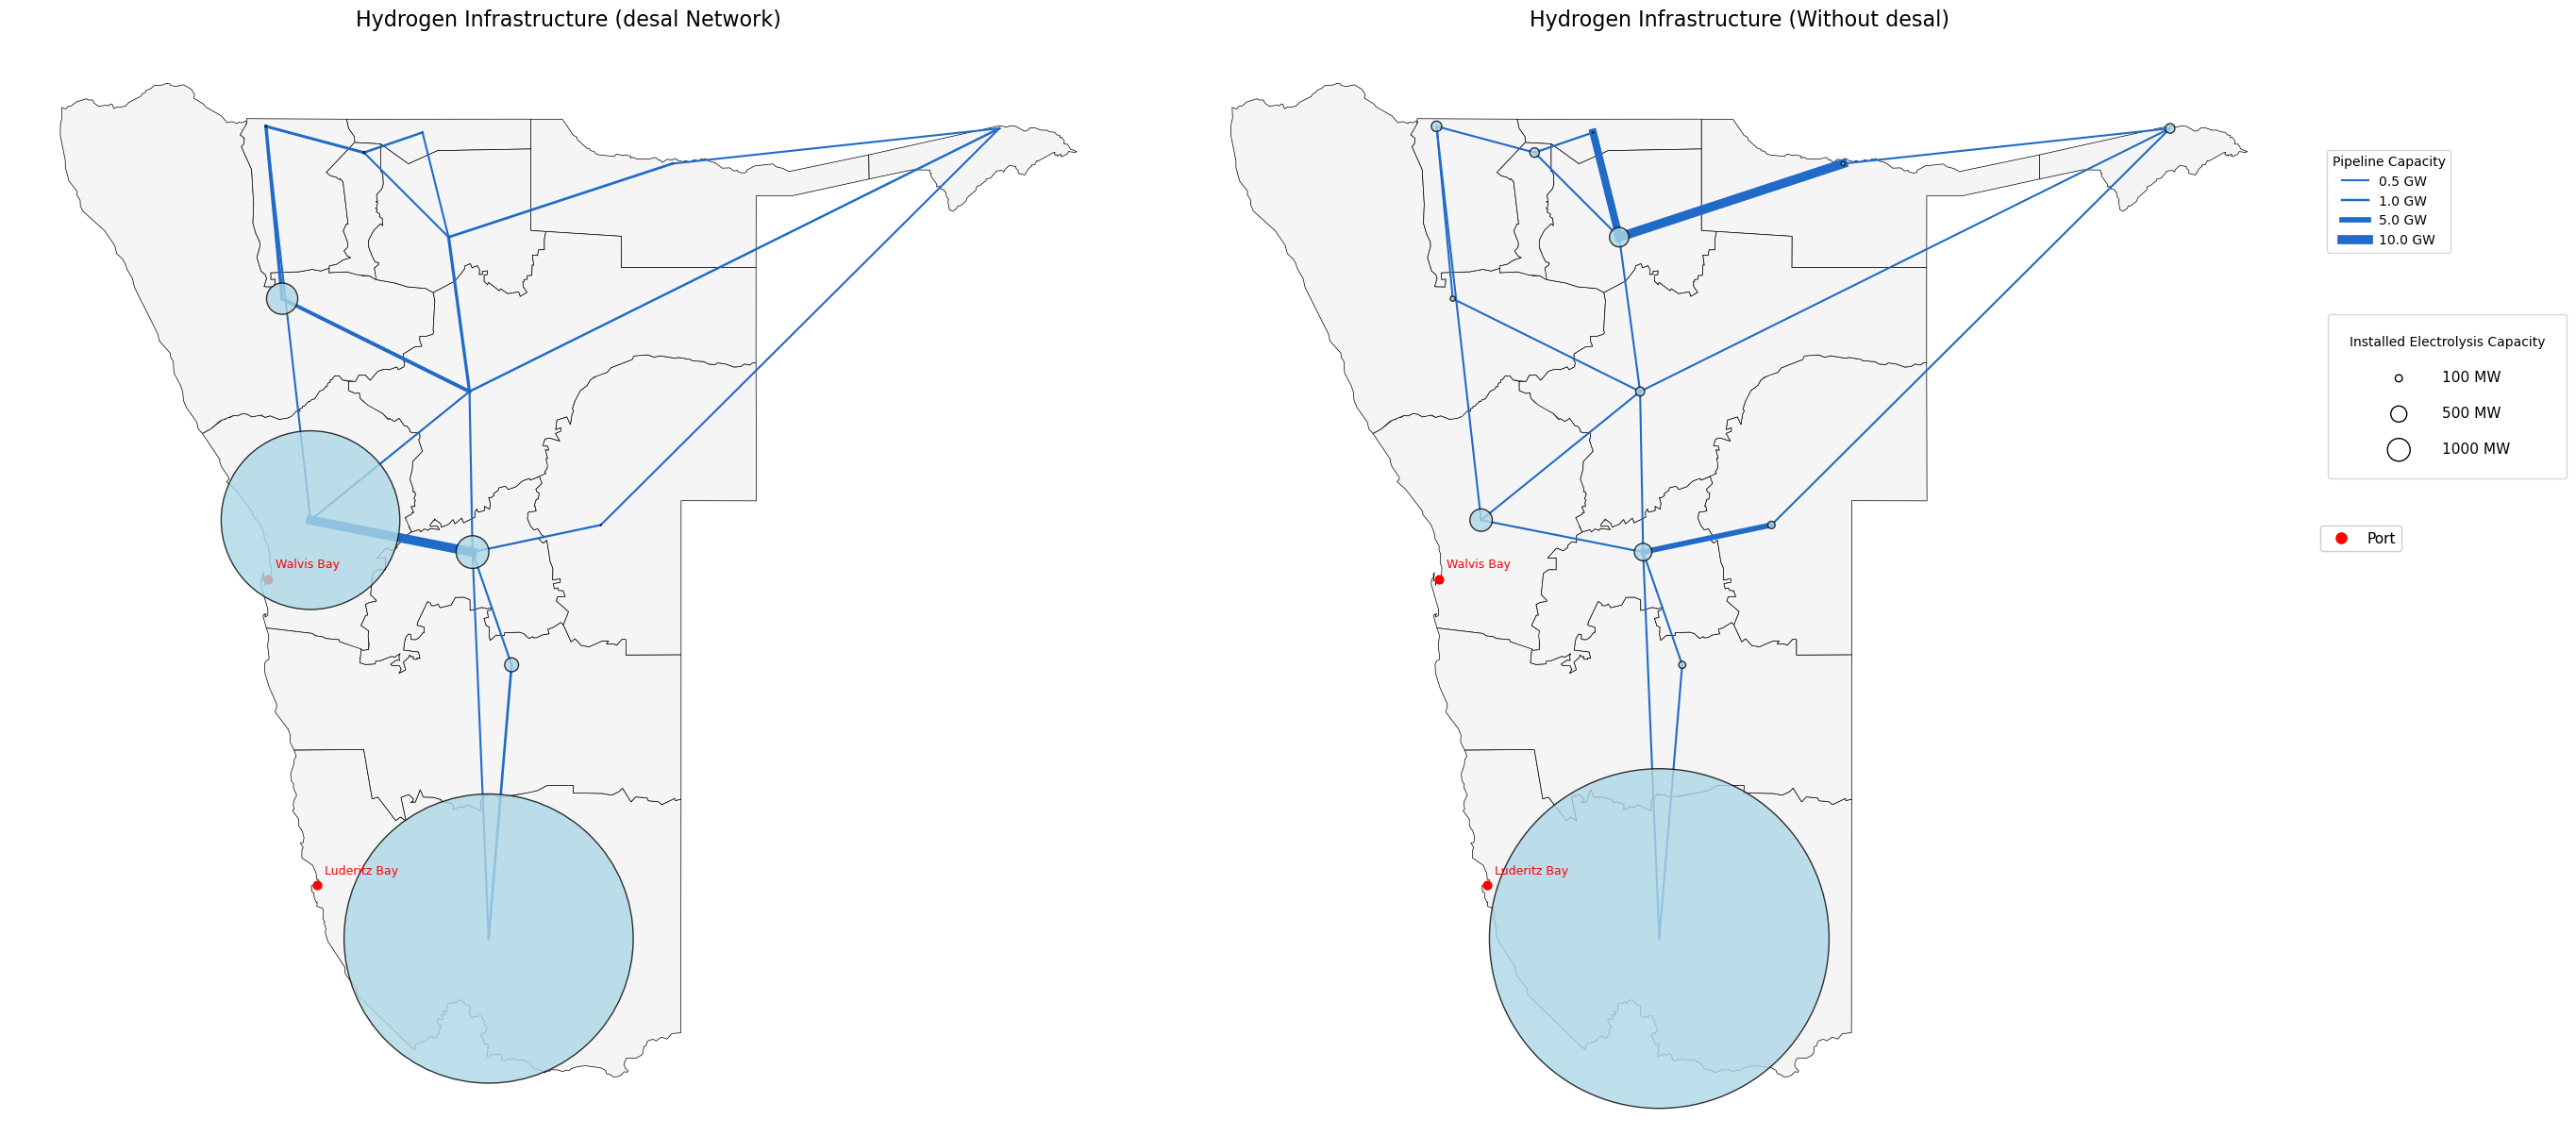

In [148]:
# --- Select, what should be shown ---
show_ports = True
show_pipelines = True
show_electrolyzers = True
show_wodesal = True

size_factor = 0.3

warnings.simplefilter(action='ignore')

def plot_infrastructure(ax, net, ports, show_pipelines,
                        show_electrolyzers, show_ports):
    """
    Draws the full hydrogen infrastructure on a given axis.

    Parameters
    ----------
    ax : matplotlib axis
        The axis to draw on.
    net : PyPSA network
        The network used for plotting (desal or wodesal).
    ports : GeoDataFrame
        Port locations.
    show_pipelines : bool
        Whether to show pipelines.
    show_electrolyzers : bool
        Whether to show electrolyzers.
    show_ports : bool
        Whether to show ports.
    """

    # --- Base map ---
    gadm_shapes.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.5)

    # --- Pipelines ---
    if show_pipelines:
        h2_pipelines = net.links[net.links.carrier.str.contains("H2 pipeline", case=False, na=False)]

        if not h2_pipelines.empty:  # <-- check if there are pipelines
            # Build pipeline geometries
            def build_pipeline_geometry(row):
                x0, y0 = net.buses.loc[row.bus0, ["x", "y"]]
                x1, y1 = net.buses.loc[row.bus1, ["x", "y"]]
                return LineString([(x0, y0), (x1, y1)])

            pipelines = h2_pipelines.copy()
            pipelines["geometry"] = pipelines.apply(build_pipeline_geometry, axis=1)

            lines_gdf = gpd.GeoDataFrame(pipelines, geometry="geometry", crs="EPSG:4326")

            if "p_nom_opt" in lines_gdf.columns:
                capacity = lines_gdf["p_nom_opt"]
                widths = np.interp(capacity, (capacity.min(), capacity.max()), (1.5, 7.0))
            else:
                widths = [1.5] * len(lines_gdf)

            # Draw pipelines
            for geom, w in zip(lines_gdf.geometry, widths):
                ax.plot(*geom.xy, color="#206bc7", linewidth=w, zorder=2)
        else:
            # No pipelines in this network, skip
            pass
        
    # --- Electrolyzers ---
    if show_electrolyzers:
    # Select electrolyzer links
        electrolysis_links = net.links[net.links.carrier == "H2 Electrolysis"]

        if not electrolysis_links.empty:
            # Installed capacity per link [MW]
            p_nom = electrolysis_links["p_nom_opt"]

            # Aggregate by bus (typically bus0)
            bus_map = electrolysis_links.bus0
            p_nom_by_bus = p_nom.groupby(bus_map).sum()  # [MW]

            # Coordinates
            coords = net.buses.loc[p_nom_by_bus.index, ["x", "y"]]

            # Visual scaling only
            sizes = p_nom_by_bus * size_factor

            ax.scatter(
                coords["x"], coords["y"],
                s=sizes,
                c="lightblue",
                alpha=0.8,
                edgecolor="k",
                zorder=3
            )

    # --- Ports ---
    if show_ports:
        # Select ports inside the region shapes
        shape_m = gadm_shapes.to_crs("EPSG:3857")
        ports_m = ports.to_crs("EPSG:3857")
        ports_within = gpd.sjoin_nearest(ports_m, shape_m, how="inner", max_distance=200).to_crs("EPSG:4326")
        ports_within.plot(ax=ax, color="red", markersize=40, marker="o")

        # Draw port labels
        for x, y, name in zip(ports_within.geometry.x,
                              ports_within.geometry.y,
                              ports_within["name"]):
            ax.annotate(name, (x + 0.1, y + 0.1),
                        fontsize=9, color="red", ha="left", va="bottom")

    ax.set_axis_off()

# --- AUTOMATIC: one or two subplots ---
if show_wodesal:
    fig, axes = plt.subplots(1, 2, figsize=(26, 12))
    ax_left = axes[0]
    ax_right = axes[1]

    # --- LEFT PANEL: desal network ---
    plot_infrastructure(
        ax_left, desal, ports, show_pipelines, show_electrolyzers, show_ports
    )
    ax_left.set_title("Hydrogen Infrastructure (desal Network)", fontsize=16)

    # --- RIGHT PANEL: network without desal ---
    plot_infrastructure(
        ax_right, wodesal, ports, show_pipelines, show_electrolyzers, show_ports
    )
    ax_right.set_title("Hydrogen Infrastructure (Without desal)", fontsize=16)

else:
    # Single plot case
    fig, ax = plt.subplots(figsize=(14, 12))
    plot_infrastructure(
        ax, desal, ports, show_pipelines, show_electrolyzers, show_ports
    )
    ax.set_title("Hydrogen Infrastructure", fontsize=16)

# --- Determine global min/max pipeline capacity from both networks ---
def get_pipeline_caps(net):
    df = net.links[net.links.carrier.str.contains("H2 pipeline", case=False, na=False)]
    if df.empty:
        return []
    return df["p_nom_opt"].values

all_caps = np.concatenate([
    get_pipeline_caps(desal),
    get_pipeline_caps(wodesal)
]) if show_wodesal else get_pipeline_caps(desal)

if len(all_caps) > 0:
    min_cap = all_caps.min()
    max_cap = all_caps.max()
else:
    min_cap, max_cap = 1, 10


# --- starting y-position for legends
legend_y = 0.9
spacing = 0.11

# Pipeline legend
if show_pipelines:
    legend_caps = [500, 1000, 5000, 10000]
    min_cap, max_cap = min(legend_caps), max(legend_caps)
    legend_widths = np.interp(legend_caps, (min_cap, max_cap), (1.5, 7.0))
    pipeline_handles = [
        mlines.Line2D([], [], color="#206bc7", linewidth=w, label=f"{cap/1000:.1f} GW")
        for cap, w in zip(legend_caps, legend_widths)
    ]
    leg1 = axes[1].legend(handles=pipeline_handles, title="Pipeline Capacity",
                           loc="upper left", bbox_to_anchor=(1.02, legend_y), fontsize=10)
    fig.add_artist(leg1)
    legend_y -= spacing

# Electrolyzer legend
if show_electrolyzers:
    example_caps = [100, 500, 1000]  # MW
    example_sizes = [c * size_factor for c in example_caps]

    bubble_handles = [
        plt.scatter([], [], s=s, facecolors="none", edgecolors="k",
                    label=f"{cap} MW")
        for s, cap in zip(example_sizes, example_caps)
    ]

    leg2 = axes[1].legend(
        handles=bubble_handles,
        title="Installed Electrolysis Capacity",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.75),
        fontsize=11,
        scatterpoints=1,
        handletextpad=2,
        borderpad=1.5,
        labelspacing=1.5
    )

    fig.add_artist(leg2)
    legend_y -= spacing

   

# Ports legend
if show_ports:
    port_handle = [mlines.Line2D([], [], color="red", marker="o", linestyle="None",
                                 markersize=8, label="Port")]
    leg3 = axes[1].legend(handles=port_handle,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.55),
        borderaxespad=0,
        fontsize=11)
    fig.add_artist(leg3)
    legend_y -= spacing


plt.tight_layout()
plt.show()

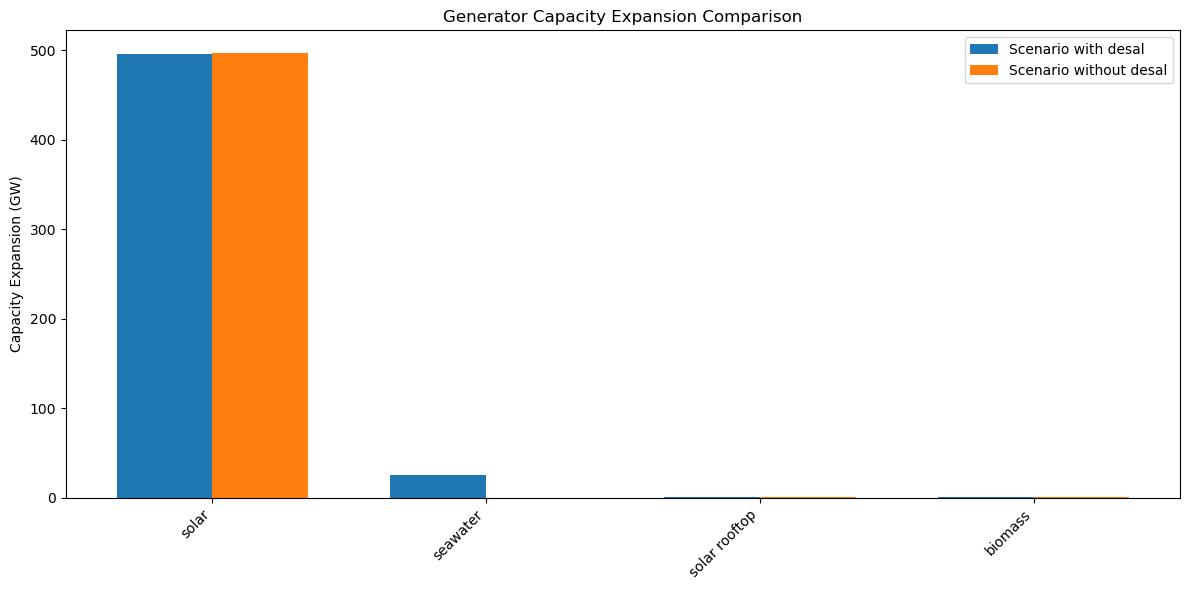

In [155]:
threshold = 0.1

def generator_capacity_expansion(n, to_gw=True, drop_zeros=True, eps=1e-6):
    """
    Returns Series indexed by carrier with expansion = sum(p_nom_opt - p_nom).
    """
    g = n.generators.copy()

    # p_nom exists for extendable and non-extendable gens; fill missing with 0
    if "p_nom" not in g.columns:
        g["p_nom"] = 0.0
    g["p_nom"] = g["p_nom"].fillna(0.0)

    # Optional: exclude load shedding if present
    g = g[g.carrier != "load shedding"]

    exp = (g["p_nom_opt"] - g["p_nom"]).groupby(g["carrier"]).sum()

    if to_gw:
        exp = exp / 1e3  # MW -> GW

    if drop_zeros:
        exp = exp[exp.abs() > eps]

    return exp.sort_values(ascending=False)

# --- Compute expansions ---
exp_desal   = generator_capacity_expansion(desal, to_gw=True, drop_zeros=False)
exp_wodesal = generator_capacity_expansion(wodesal, to_gw=True, drop_zeros=False)

# Align carriers across scenarios
df_expansion = pd.concat(
    [exp_desal.rename("Scenario with desal"), exp_wodesal.rename("Scenario without desal")],
    axis=1
).fillna(0.0)


df_expansion = df_expansion[(df_expansion.abs().max(axis=1) > threshold)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.35
x = np.arange(len(df_expansion.index))

ax.bar(x - width/2, df_expansion["Scenario with desal"], width, color=SCENARIO_COLORS["desal"], label="Scenario with desal")
ax.bar(x + width/2, df_expansion["Scenario without desal"], width, color=SCENARIO_COLORS["wodesal"], label="Scenario without desal")

ax.set_xticks(x)
ax.set_xticklabels(df_expansion.index, rotation=45, ha="right")
ax.set_ylabel("Capacity Expansion (GW)")
ax.set_title("Generator Capacity Expansion Comparison")
ax.legend()

plt.tight_layout()
plt.show()


H2O Storage capacity extension: 6222.306953628753 GWh


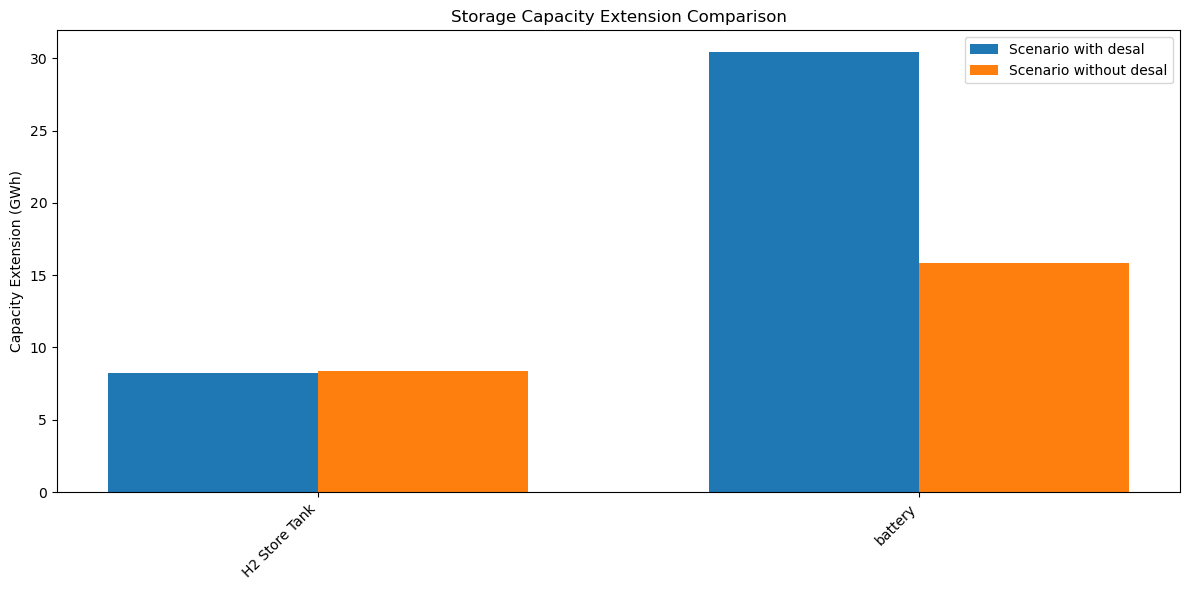

In [159]:
threshold = 1e-1

def storage_extension_GWh(n):
    stores = n.stores.copy()
    # If e_nom exists, compute added capacity; else fall back to e_nom_opt
    if "e_nom" in stores.columns:
        ext_MWh = (stores["e_nom_opt"] - stores["e_nom"]).clip(lower=0)
    else:
        ext_MWh = stores["e_nom_opt"].fillna(0)
    return ext_MWh.groupby(stores["carrier"]).sum() / 1e3  # GWh

desal_storage_extension = storage_extension_GWh(desal)
wodesal_storage_extension = storage_extension_GWh(wodesal)

print("H2O Storage capacity extension:" , desal_storage_extension.get("H2O store", 0), "GWh")

# --- Filter unwanted carriers ---
exclude_carriers = ["gas", "co2", "oil", "solid biomass", "H2", "coal", "biomass", "biogas", "co2 stored", "H2O store"]
desal_storage_extension = desal_storage_extension[~desal_storage_extension.index.isin(exclude_carriers)]
wodesal_storage_extension = wodesal_storage_extension[~wodesal_storage_extension.index.isin(exclude_carriers)]

# Filter out carriers with zero capacity extension
desal_storage_extension = desal_storage_extension[desal_storage_extension > threshold]
wodesal_storage_extension = wodesal_storage_extension[wodesal_storage_extension > threshold]

# Combine for consistent order
all_carriers = sorted(set(desal_storage_extension.index) | set(wodesal_storage_extension.index))
desal_storage_extension = desal_storage_extension.reindex(all_carriers, fill_value=0)
wodesal_storage_extension = wodesal_storage_extension.reindex(all_carriers, fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35  # Width of the bars
x = np.arange(len(all_carriers))  # Carrier positions on x-axis

# Bars for desal scenario
ax.bar(x - width/2, desal_storage_extension, width, color=SCENARIO_COLORS["desal"], label="Scenario with desal")

# Bars for wodesal scenario
ax.bar(x + width/2, wodesal_storage_extension, width, color=SCENARIO_COLORS["wodesal"], label="Scenario without desal")

# Axis labels and title
ax.set_xticks(x)
ax.set_xticklabels(all_carriers, rotation=45, ha="right")
ax.set_ylabel("Capacity Extension (GWh)")
ax.set_title("Storage Capacity Extension Comparison")

# Legend
ax.legend()

plt.tight_layout()
plt.show()

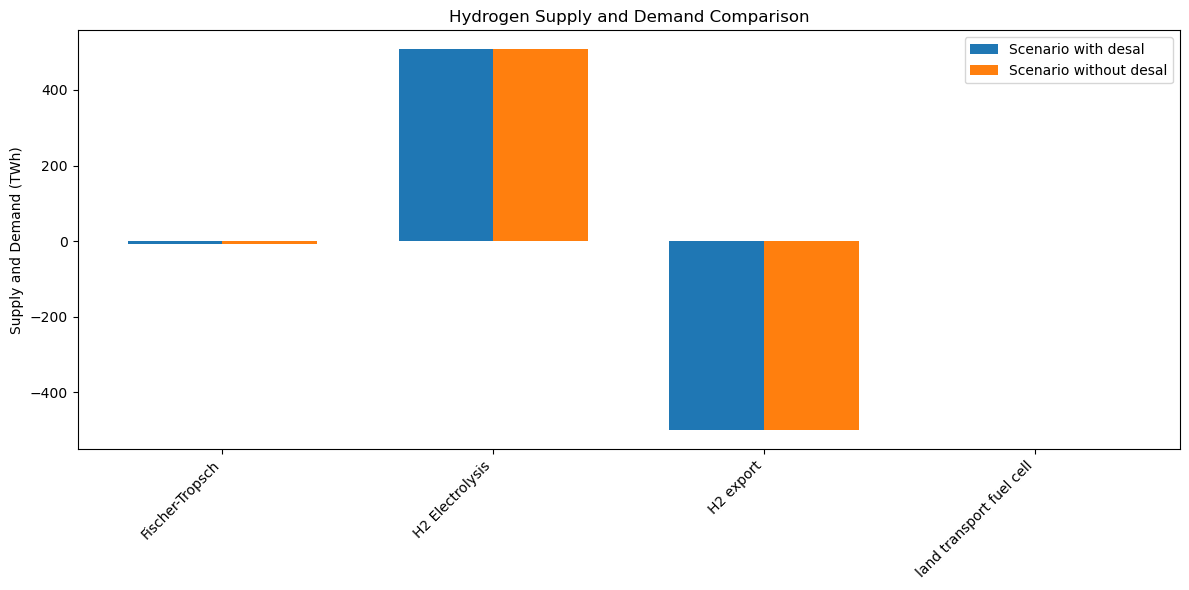

In [123]:
threshold = 1e-1
# --- Extract hydrogen-related capacities ---#
# Extract hydrogen-related energy balances for desal and wodesal
desal_hydrogen_balance = desal.statistics.energy_balance().loc[:, :, "H2"].groupby("carrier").sum().div(1e6)  # Convert to TWh
wodesal_hydrogen_balance = wodesal.statistics.energy_balance().loc[:, :, "H2"].groupby("carrier").sum().div(1e6)  # Convert to TWh
# Combine for consistent order
all_hydrogen_carriers = sorted(set(desal_hydrogen_balance.index) | set(wodesal_hydrogen_balance.index))
desal_hydrogen_balance = desal_hydrogen_balance.reindex(all_hydrogen_carriers, fill_value=0)
wodesal_hydrogen_balance = wodesal_hydrogen_balance.reindex(all_hydrogen_carriers, fill_value=0)

# --- Filter: keep only carriers with actual (non-zero) energy flows in either scenario ---
combined_balance = desal_hydrogen_balance.abs() + wodesal_hydrogen_balance.abs()

mask = combined_balance > threshold

desal_hydrogen_balance = desal_hydrogen_balance[mask]
wodesal_hydrogen_balance = wodesal_hydrogen_balance[mask]
all_hydrogen_carriers = desal_hydrogen_balance.index.tolist()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35  # Width of the bars
x = np.arange(len(all_hydrogen_carriers))  # Carrier positions on x-axis

# Bars for desal scenario
ax.bar(x - width/2, desal_hydrogen_balance, width, color=SCENARIO_COLORS["desal"], label="Scenario with desal")

# Bars for wodesal scenario
ax.bar(x + width/2, wodesal_hydrogen_balance, width, color=SCENARIO_COLORS["wodesal"], label="Scenario without desal")

# Axis labels and title
ax.set_xticks(x)
ax.set_xticklabels(all_hydrogen_carriers, rotation=45, ha="right")
ax.set_ylabel("Supply and Demand (TWh)")
ax.set_title("Hydrogen Supply and Demand Comparison")

# Legend
ax.legend()

plt.tight_layout()
plt.show()

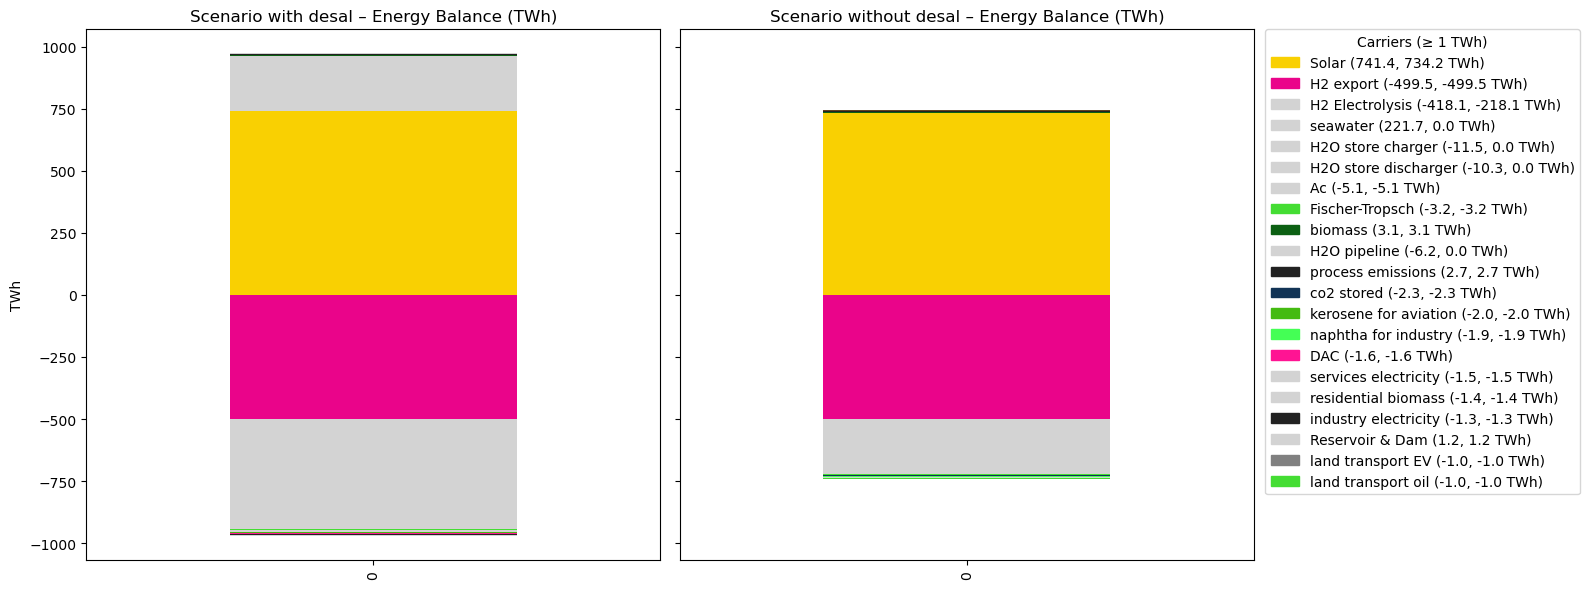

In [160]:
# =========================
# User-adjustable threshold
# =========================
THRESHOLD_TWH = 0.1   # hide carriers with |value| < 0.1 TWh in BOTH scenarios
LEGEND_THRESHOLD_TWH = 1  # show only carriers >= 10 TWh in legend

def compute_energy_balance(n: pypsa.Network) -> pd.Series:
    rename_cols = {
        "-": "Load",
        "load": "load shedding",
    }

    # Aggregate energy balance by carrier and convert MWh -> TWh
    eb = (
        n.statistics.energy_balance()
        .loc[:, :, :]
        .groupby("carrier")
        .sum()
        .div(1e6)  # MWh -> TWh
        .rename(index=rename_cols)
    )

    # If result is a DataFrame (multiple columns), reduce to a single number per carrier
    if isinstance(eb, pd.DataFrame):
        eb = eb.sum(axis=1)

    return eb.fillna(0.0)


# --- Compute data (as Series) ---
s_desal = compute_energy_balance(desal)
s_wodesal = compute_energy_balance(wodesal)

# Harmonize index (carriers) between scenarios
all_carriers = sorted(set(s_desal.index) | set(s_wodesal.index))
s_desal = s_desal.reindex(all_carriers, fill_value=0.0)
s_wodesal = s_wodesal.reindex(all_carriers, fill_value=0.0)

# --- Apply threshold: keep only carriers with meaningful flows in either scenario ---
mask = (s_desal.abs() >= THRESHOLD_TWH) | (s_wodesal.abs() >= THRESHOLD_TWH)
s_desal = s_desal.loc[mask]
s_wodesal = s_wodesal.loc[mask]

# Sort carriers by combined absolute magnitude (more stable than raw sum if signs mix)
order = (s_desal.abs() + s_wodesal.abs()).sort_values(ascending=False).index.tolist()
s_desal = s_desal.reindex(order)
s_wodesal = s_wodesal.reindex(order)

# Convert to 1-row DataFrames for your bar plotting style
df_desal = s_desal.to_frame().T
df_wodesal = s_wodesal.to_frame().T

# --- Assign colors ---
colors = [get_color(c) for c in order]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df_desal.plot.bar(
    stacked=True,
    ax=axes[0],
    legend=False,
    title="Scenario with desal – Energy Balance (TWh)",
    color=colors
)
axes[0].set_xlabel("")
axes[0].set_ylabel("TWh")

df_wodesal.plot.bar(
    stacked=True,
    ax=axes[1],
    legend=False,
    title="Scenario without desal – Energy Balance (TWh)",
    color=colors
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# --- Manually build the legend (threshold-controlled) ---
labels, handles = [], []
for c, col in zip(order, colors):
    val_desal = float(df_desal.iloc[0][c])
    val_wodesal = float(df_wodesal.iloc[0][c])

    if (abs(val_desal) >= LEGEND_THRESHOLD_TWH) or (abs(val_wodesal) >= LEGEND_THRESHOLD_TWH):
        labels.append(f"{c} ({val_desal:.1f}, {val_wodesal:.1f} TWh)")
        handles.append(plt.Rectangle((0, 0), 1, 1, color=col))

axes[1].legend(
    handles,
    labels,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    title=f"Carriers (≥ {LEGEND_THRESHOLD_TWH} TWh)"
)

plt.tight_layout()
plt.show()


#### Hydrogen prices

In [127]:
# procentual splitting of LCOH / LCOA, what percentage is water for desal and woDesal 2050 next to each other

In [128]:
# plot LCOH, Hydrogen CAPEX & OPEX, hydrogen supply and revenue for desal and woDesal next to each other

In [129]:
# plot Hydrogen Market value, hydrogen costs, hydrogen exports (prices + quantity + revenue), hydrogen capacity for desal and woDesal 2050 next to each other

In [130]:
# plot LCOH + transport for wodesal, desal, desalx2, desalx4 2050 + LCOH Germany 2050

#### Show PV and Wind Potential

In [131]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"../../../pypsa-earth/resources/desal/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

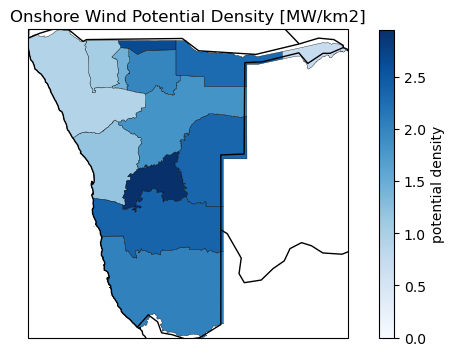

In [132]:
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

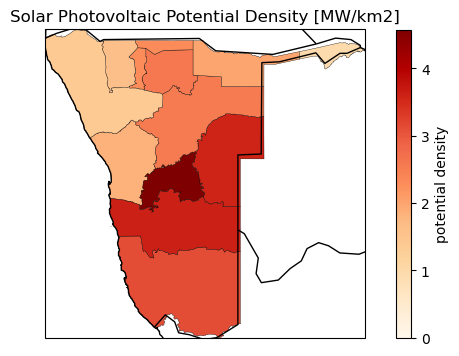

In [133]:
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger("pypsa.io").setLevel(logging.ERROR)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

#### Sensitivity Analysis

In [134]:
# Graph LCOH mit verscheiden WACCs, technology costs, water usage, temporal resolution

In [135]:
# compare price stabilizing effect results with and without temporal matching activated

#### Appendix

In [136]:
# Compare PyPSA Generators with national statistics of power plants